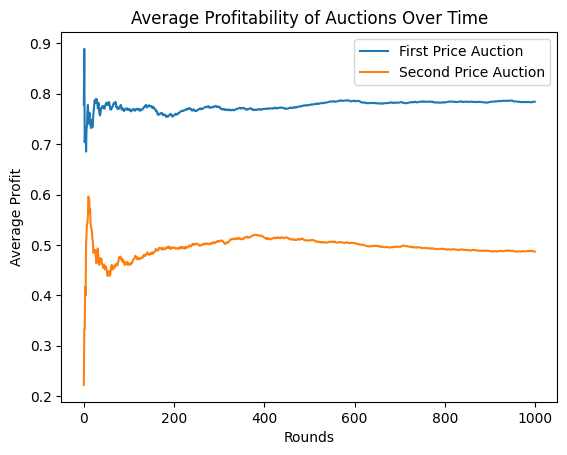

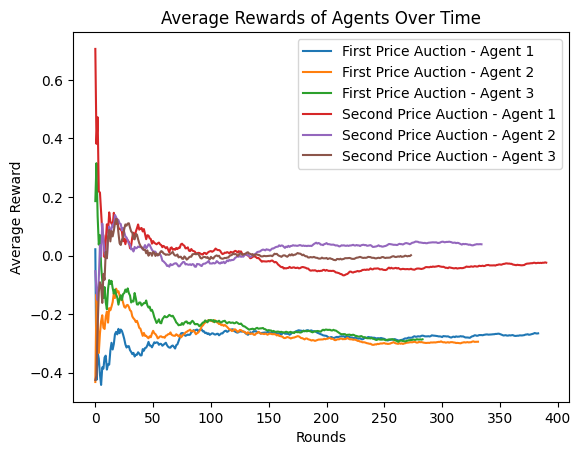

In [19]:
import numpy as np
import matplotlib.pyplot as plt

class ZeroIntelligenceAgent:
    def __init__(self, valuation_distribution=lambda: np.random.uniform(0, 1), action_min=0, action_max=1, granularity=10):
        self.valuation_distribution = valuation_distribution
        self.actions = np.linspace(action_min, action_max, granularity)
        self.reward_history = []
        self.valuation = self.valuation_distribution()
    
    def refresh_valuation(self):
        self.valuation = self.valuation_distribution()
    
    def choose_action(self):
        return np.random.choice(self.actions)
    
    def record_reward(self, reward):
        self.reward_history.append(reward)

class SingleSidedAuction:
    def __init__(self, agents, cost_distribution=lambda: 0, price_floor=0, price_ceiling=1, payment_rule=None, winner_rule=None):
        self.agents = agents
        self.price_floor = price_floor
        self.price_ceiling = price_ceiling
        self.payment_rule = payment_rule
        self.winner_rule = winner_rule
        self.cost_distribution = cost_distribution
        self.profit_history = []
        self.cost = self.cost_distribution()
    
    def refresh_cost(self):
        self.cost = self.cost_distribution()
    
    def run_auction(self):
        for agent in self.agents:
            agent.refresh_valuation()
        self.refresh_cost()
        
        bids = [max(self.price_floor, min(agent.choose_action(), self.price_ceiling)) for agent in self.agents]
        winner_index, payment = self.winner_rule(bids)
        reward = self.agents[winner_index].valuation - payment
        cost = self.cost
        profit = payment - cost
        self.agents[winner_index].record_reward(reward)
        self.profit_history.append(profit)
        return {"winner": winner_index, "payment": payment, "profit": profit, "reward": reward, "bids": bids}

def first_price_rule(bids):
    winner_index = np.argmax(bids)
    payment = bids[winner_index]
    return winner_index, payment

def second_price_rule(bids):
    winner_index = np.argmax(bids)
    sorted_bids = np.sort(bids)
    if len(bids) > 1:
        payment = sorted_bids[-2]  # Second highest bid
    else:
        payment = sorted_bids[-1]
    return winner_index, payment

def run_simulation(agents, game, num_repetitions):
    for _ in range(num_repetitions):
        game.run_auction()
    return [agent.reward_history for agent in agents]

def plot_auction_profitability(games, labels):
    for game, label in zip(games, labels):
        plt.plot(np.cumsum(game.profit_history) / (np.arange(len(game.profit_history)) + 1), label=f'{label}')
    plt.title('Average Profitability of Auctions Over Time')
    plt.xlabel('Rounds')
    plt.ylabel('Average Profit')
    plt.legend()
    plt.show()

def plot_agents_rewards(agent_groups, labels):
    for agents, label in zip(agent_groups, labels):
        for idx, agent in enumerate(agents):
            avg_rewards = np.cumsum(agent.reward_history) / (np.arange(len(agent.reward_history)) + 1)
            plt.plot(avg_rewards, label=f'{label} - Agent {idx+1}')
    plt.title('Average Rewards of Agents Over Time')
    plt.xlabel('Rounds')
    plt.ylabel('Average Reward')
    plt.legend()
    plt.show()

if __name__ == "__main__":
    np.random.seed(0)
    
    # Set default distributions (already in the class)
    cost_distribution = lambda: 0  # Costs default to 0

    # Create agents for first price and second price auctions
    agents_fp = [ZeroIntelligenceAgent() for _ in range(3)]
    agents_sp = [ZeroIntelligenceAgent() for _ in range(3)]

    # First Price Auction
    first_price_auction = SingleSidedAuction(
        agents_fp, 
        cost_distribution, 
        price_floor=0, 
        price_ceiling=1, 
        payment_rule=first_price_rule, 
        winner_rule=first_price_rule
    )

    # Second Price Auction
    second_price_auction = SingleSidedAuction(
        agents_sp, 
        cost_distribution, 
        price_floor=0, 
        price_ceiling=1, 
        payment_rule=second_price_rule, 
        winner_rule=second_price_rule
    )

    # Run the simulations for 1000 repetitions
    run_simulation(agents=agents_fp, game=first_price_auction, num_repetitions=1000)
    run_simulation(agents=agents_sp, game=second_price_auction, num_repetitions=1000)

    # Plot auction profitability for both auctions
    plot_auction_profitability([first_price_auction, second_price_auction], ['First Price Auction', 'Second Price Auction'])

    # Plot agents' average rewards for both auctions
    plot_agents_rewards([agents_fp, agents_sp], ['First Price Auction', 'Second Price Auction'])

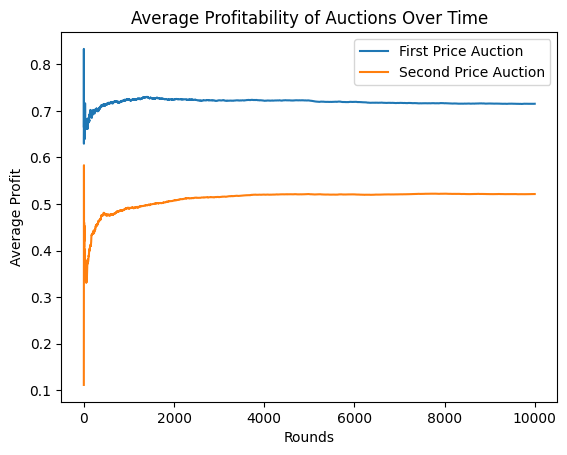

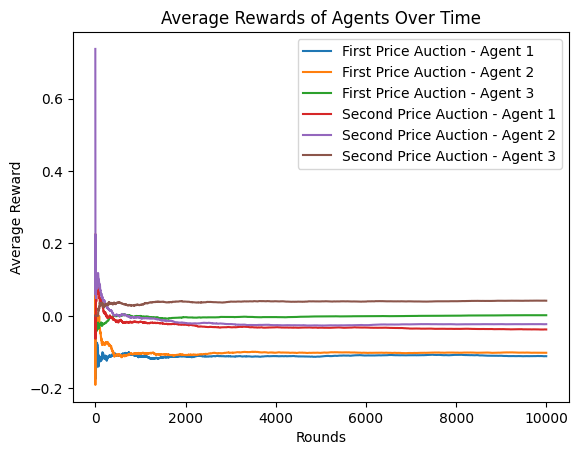

In [31]:
import numpy as np
import matplotlib.pyplot as plt

class ZeroIntelligenceAgent:
    def __init__(self, valuation_distribution=lambda: np.random.uniform(0, 1), action_min=0, action_max=1, granularity=10):
        self.valuation_distribution = valuation_distribution
        self.actions = np.linspace(action_min, action_max, granularity)
        self.reward_history = []
        self.valuation = self.valuation_distribution()
    
    def refresh_valuation(self):
        self.valuation = self.valuation_distribution()
    
    def choose_action(self):
        return np.random.choice(self.actions)
    
    def feedback(self, reward, *args):
        self.reward_history.append(reward)

class EpsilonGreedyAgent:
    def __init__(self, valuation_distribution=lambda: np.random.uniform(0, 1), action_min=0, action_max=1, granularity=10, epsilon=0.1):
        self.valuation_distribution = valuation_distribution
        self.actions = np.linspace(action_min, action_max, granularity)
        self.epsilon = epsilon
        self.valuation = self.valuation_distribution()
        self.q_values = np.zeros(len(self.actions))
        self.action_counts = np.zeros(len(self.actions))
        self.reward_history = []
    
    def refresh_valuation(self):
        self.valuation = self.valuation_distribution()
    
    def choose_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.actions)  # Exploration
        else:
            return self.actions[np.argmax(self.q_values)]  # Exploitation
    
    def update_q_values(self, chosen_action, reward):
        action_index = np.where(self.actions == chosen_action)[0][0]
        self.action_counts[action_index] += 1
        alpha = 1 / self.action_counts[action_index]  # Learning rate
        self.q_values[action_index] += alpha * (reward - self.q_values[action_index])
    
    def feedback(self, reward, action):
        self.reward_history.append(reward)
        self.update_q_values(action, reward)

class SingleSidedAuction:
    def __init__(self, agents, cost_distribution=lambda: 0, price_floor=0, price_ceiling=1, payment_rule=None, winner_rule=None):
        self.agents = agents
        self.price_floor = price_floor
        self.price_ceiling = price_ceiling
        self.payment_rule = payment_rule
        self.winner_rule = winner_rule
        self.cost_distribution = cost_distribution
        self.profit_history = []
        self.cost = self.cost_distribution()
    
    def refresh_cost(self):
        self.cost = self.cost_distribution()
    
    def run_auction(self):
        for agent in self.agents:
            agent.refresh_valuation()
        self.refresh_cost()
        
        bids = [max(self.price_floor, min(agent.choose_action(), self.price_ceiling)) for agent in self.agents]
        winner_index, payment = self.winner_rule(bids)
        reward = self.agents[winner_index].valuation - payment
        cost = self.cost
        profit = payment - cost
        
        # Record feedback for all agents (0 for non-winners)
        for idx, agent in enumerate(self.agents):
            agent.feedback(reward if idx == winner_index else 0, bids[idx])
        
        self.profit_history.append(profit)
        return {"winner": winner_index, "payment": payment, "profit": profit, "reward": reward, "bids": bids}

def first_price_rule(bids):
    winner_index = np.argmax(bids)
    payment = bids[winner_index]
    return winner_index, payment

def second_price_rule(bids):
    winner_index = np.argmax(bids)
    sorted_bids = np.sort(bids)
    if len(bids) > 1:
        payment = sorted_bids[-2]  # Second highest bid
    else:
        payment = sorted_bids[-1]
    return winner_index, payment

def run_simulation(agents, game, num_repetitions):
    for _ in range(num_repetitions):
        game.run_auction()
    return [agent.reward_history for agent in agents]

def plot_auction_profitability(games, labels):
    for game, label in zip(games, labels):
        plt.plot(np.cumsum(game.profit_history) / (np.arange(len(game.profit_history)) + 1), label=f'{label}')
    plt.title('Average Profitability of Auctions Over Time')
    plt.xlabel('Rounds')
    plt.ylabel('Average Profit')
    plt.legend()
    plt.show()

def plot_agents_rewards(agent_groups, labels):
    for agents, label in zip(agent_groups, labels):
        for idx, agent in enumerate(agents):
            avg_rewards = np.cumsum(agent.reward_history) / (np.arange(len(agent.reward_history)) + 1)
            plt.plot(avg_rewards, label=f'{label} - Agent {idx+1}')
    plt.title('Average Rewards of Agents Over Time')
    plt.xlabel('Rounds')
    plt.ylabel('Average Reward')
    plt.legend()
    plt.show()

if __name__ == "__main__":
    np.random.seed(0)
    
    # Set default distributions (already in the class)
    cost_distribution = lambda: 0  # Costs default to 0

    # Create agents for first price and second price auctions
    agents_fp = [ZeroIntelligenceAgent(), ZeroIntelligenceAgent(), EpsilonGreedyAgent()]  # Third agent is EpsilonGreedyAgent
    agents_sp = [ZeroIntelligenceAgent(), ZeroIntelligenceAgent(), EpsilonGreedyAgent()]

    # First Price Auction
    first_price_auction = SingleSidedAuction(
        agents_fp, 
        cost_distribution, 
        price_floor=0, 
        price_ceiling=1, 
        payment_rule=first_price_rule, 
        winner_rule=first_price_rule
    )

    # Second Price Auction
    second_price_auction = SingleSidedAuction(
        agents_sp, 
        cost_distribution, 
        price_floor=0, 
        price_ceiling=1, 
        payment_rule=second_price_rule, 
        winner_rule=second_price_rule
    )

    # Run the simulations for 1000 repetitions
    N = 10000
    run_simulation(agents=agents_fp, game=first_price_auction, num_repetitions=N)
    run_simulation(agents=agents_sp, game=second_price_auction, num_repetitions=N)

    # Plot auction profitability for both auctions
    plot_auction_profitability([first_price_auction, second_price_auction], ['First Price Auction', 'Second Price Auction'])

    # Plot agents' average rewards for both auctions
    plot_agents_rewards([agents_fp, agents_sp], ['First Price Auction', 'Second Price Auction'])


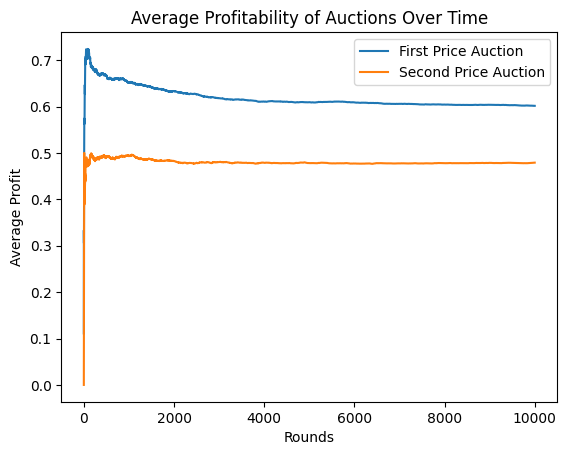

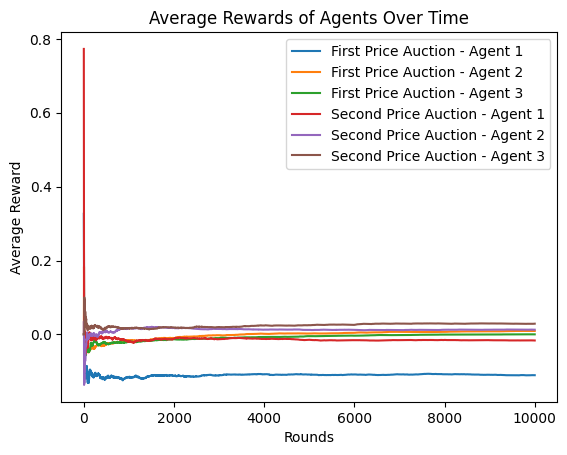

In [41]:
class UCBAgent:
    def __init__(self, valuation_distribution=lambda: np.random.uniform(0, 1), action_min=0, action_max=1, granularity=10, c=2):
        self.valuation_distribution = valuation_distribution
        self.actions = np.linspace(action_min, action_max, granularity)
        self.valuation = self.valuation_distribution()
        self.q_values = np.zeros(len(self.actions))
        self.action_counts = np.zeros(len(self.actions))
        self.total_count = 0
        self.reward_history = []
        self.c = c  # Exploration parameter for UCB
    
    def refresh_valuation(self):
        self.valuation = self.valuation_distribution()
    
    def choose_action(self):
        self.total_count += 1
        ucb_values = self.q_values + self.c * np.sqrt(np.log(self.total_count + 1) / (self.action_counts + 1e-5))
        return self.actions[np.argmax(ucb_values)]
    
    def update_q_values(self, chosen_action, reward):
        action_index = np.where(self.actions == chosen_action)[0][0]
        self.action_counts[action_index] += 1
        alpha = 1 / self.action_counts[action_index]  # Learning rate
        self.q_values[action_index] += alpha * (reward - self.q_values[action_index])
    
    def feedback(self, reward, action):
        self.reward_history.append(reward)
        self.update_q_values(action, reward)

if __name__ == "__main__":
    np.random.seed(0)
    
    # Set default distributions (already in the class)
    cost_distribution = lambda: 0  # Costs default to 0

    # Create agents for first price and second price auctions
    agents_fp = [ZeroIntelligenceAgent(), UCBAgent(), UCBAgent()]  # Third agent is UCBAgent
    agents_sp = [ZeroIntelligenceAgent(), UCBAgent(), UCBAgent()]

    # First Price Auction
    first_price_auction = SingleSidedAuction(
        agents_fp, 
        cost_distribution, 
        price_floor=0, 
        price_ceiling=1, 
        payment_rule=first_price_rule, 
        winner_rule=first_price_rule
    )

    # Second Price Auction
    second_price_auction = SingleSidedAuction(
        agents_sp, 
        cost_distribution, 
        price_floor=0, 
        price_ceiling=1, 
        payment_rule=second_price_rule, 
        winner_rule=second_price_rule
    )

    # Run the simulations for 1000 repetitions
    N = 10000
    run_simulation(agents=agents_fp, game=first_price_auction, num_repetitions=N)
    run_simulation(agents=agents_sp, game=second_price_auction, num_repetitions=N)

    # Plot auction profitability for both auctions
    plot_auction_profitability([first_price_auction, second_price_auction], ['First Price Auction', 'Second Price Auction'])

    # Plot agents' average rewards for both auctions
    plot_agents_rewards([agents_fp, agents_sp], ['First Price Auction', 'Second Price Auction'])
